# Feature analysis — Order-Flow Imbalance (OFI), a fast/slow family — **path-sum variant**

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

> **Path-sum variant.** A burst of byb book updates at one nanosecond is **one** EMA sample whose
> value is the **sum** of the per-row Cont–Kukanov–Stoikov OFI increments (the full intra-ns book
> path), not the single increment of the collapsed final book (endpoint). The EMA still takes **at most
> one** sample per timestamp and decays once per shared-trade-clock tick — only the injected *value*
> changes. So it differs from an endpoint build only on venues with multiple book updates per timestamp
> (**bin**); byb/okx are essentially unaffected.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`ofi` function in §3. The data loading, the checks, and the plots adapt on their own.

**The example** is `ofi`: how lop-sided the *changes* in byb's best bid/ask have been lately —
buy-side replenishment minus sell-side, summed over recent book updates, read as a fast-EMA **minus**
a slow-EMA of that flow. A run of bid-building and ask-pulling (positive OFI) is order flow leaning up;
the prediction is that byb's mid follows. It is built **from each venue's own book** (single-venue, but
swept symmetrically over all three) — and it touches every step of the method.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own. And they
are **marginal screens** — does the feature carry signal worth feeding — **not** measures of
distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature (this OFI *is* poolable — a per-exchange own-book number, not a gap *between*
  exchanges), first check per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — OFI's `fast − slow` is a self-centred **difference** of two same-units `E/W` legs,
  already comparable across markets, so it needs **no** `σ_ev` division. (Contrast the template's
  price gap, which is bigger when volatile and so *must* be divided by `σ_ev`.)
- **Don't invent your own vol/rate scale.** When you do normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — the OFI legs,
  `σ_ev`, `λ_ev`, any rolling statistic — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a byb book update — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update). For OFI, that relevant event is a byb
  book update: it injects that timestamp's summed OFI increment. A leg that ignores the book updates since
  the last trade is **stale** — wrong, and a silent source of lag. The choice of EMA *and when it updates*
  is what makes the inter-trade read well-behaved — pick both deliberately (see the "Choosing the EMA" section).
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for OFI, a byb book update; for `σ_ev`, a byb mid-move. A timestamp with only
  **irrelevant** trades injects nothing for that EMA, yet it still
  **ticks** (decays) once *iff* a trade lands, on the one **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. *What* value depends on the quantity: a **level**
  read takes the *last* state (mid, microprice); a **flow** **sums** the records at that timestamp
  (trade volume; **OFI sums its intra-timestamp per-row increments** — the path-sum). So a backed-up burst
  of N book updates at one instant is still **one** weight-1 sample — value = the summed intra-ns OFI path —
  **never** N samples. Injecting N silently overweights exactly the instants where a feed stalled and
  dumped a burst (N× weight on the `E/W` mean at one timestamp) and corrupts the count `W` that
  normalises it.
- **Do read a sparse flow as `E / W`.** A quantity present on only *some* events (OFI on byb book updates;
  byb's own mid-moves — `σ_ev` is itself such an `E / W`) still needs the
  trade-tick EMA, but as **two** of them — the value `E` and its weight `W`, both decayed every
  trade-timestamp yet each pushed a sample only at the timestamps carrying its own events — read as the ratio `E / W`, which cancels the
  in-between decay and the warm-up bias. Dividing by `W` cancels the foreign-event decay exactly,
  so an `E / W` on the **combined** trade clock at span `N` approximates that exchange's **own**-clock
  EMA at a rescaled span — roughly `N` times that exchange's share of the combined trade rate — i.e. you get genuine per-exchange stats from the one shared clock. (That
  merged-clock ↔ own-clock equivalence — tight at large `N`, fraying at small `N` where the
  cross-venue lead/lag lives — is what `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** Check whether the
  signed feature predicts *direction* (price head) and whether its *magnitude* predicts
  *intensity* (rate head). Those checks are diagnostics — in the model, feed the **signed**
  feature to *both* heads, never a pre-computed `|feature|`. The rate head will learn the
  magnitude itself, *and* learn that buy pressure on one venue's book can cancel sell pressure on another
  (or reinforce it). Pre-taking `|·|` per feature destroys the sign and that interaction.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass (a self-centred fast-minus-slow oscillator is
  exactly such a form), and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | level-1 order-flow imbalance of an exchange's own book, read as a fast-EMA **minus** a slow-EMA over two time-scales |
| **feeds** | both heads — *direction* (price head: which way byb moves) and *intensity* (rate head: how many moves); both are fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** Each time a book's top-of-book changes, the **OFI increment** counts the net depth added
on the buy side minus the sell side (definition in §2). Positive means bids built / asks were pulled —
buying pressure; negative the reverse. Sum these increments into a *fast* EMA and a *slow* EMA, and take
their **difference** `fast − slow`. The slow EMA is the prevailing flow baseline; the fast EMA is the
recent flow. A fast that is larger than the slow says buy/sell pressure has just intensified in that
direction — and the prediction is byb's mid follows.

> **Why a difference, not a ratio.** An earlier cut of this feature used the *ratio* `fast / slow`. That
> is wrong for a **signed direction** feature: the ratio **inverts sign** every time the slow leg crosses
> zero (a small negative baseline flips a positive fast leg to a large *negative* reading), so "lean up"
> and "lean down" get swapped exactly when the baseline is near zero. The **difference** `fast − slow`
> never inverts: its sign is the sign of *(recent flow − baseline flow)*, which is what we mean. It is
> also the form whose two legs are each a clean `E/W` mean, so the §4 parity check is genuinely **bit-exact**
> (no near-zero-denominator blow-up to relabel away).

**Why it should work.** OFI is the most direct microstructure read of **net pressure on the quote**:
the Cont–Kukanov–Stoikov result is that contemporaneous mid-price changes are close to *linear* in
OFI, with depth setting the slope. If OFI also *leads* the mid by tens of milliseconds — the
replenishment shows in the book a beat before the mid prints — then recent OFI predicts the next move.
The fast-minus-slow **oscillator** (rather than a raw level) is self-centring: it asks "is flow leaning
harder than its own recent baseline?", so it stays comparable as depth and activity drift through the day.

**Why a difference (and no σ-division).** Both legs share the same depth/activity units (depth × weight),
so their difference is already comparable across the day — no explicit `σ_ev` division is needed, exactly
the "don't normalise a self-centred feature" guard rail. (We still build `σ_ev`, `λ_ev` below: the *target*
is in σ-units, and they are the regime controls in §5.)

**What would disprove it.** No predictive power at any fast/slow pair, or power that vanishes once we
control for how volatile / busy the market is (meaning OFI was only a volatility proxy).

> **Single-venue, every exchange kept.** OFI is built from **each venue's own** book (the target's book
> most directly precedes byb's mid, but the same construction generalises to every venue). We never
> privilege one; we sweep all three symmetrically and keep them all. §9 frames the per-exchange-vs-pool
> question for this poolable feature.

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). OFI is a **sparse flow** — it carries a value
only on a byb **book update** — so it is the textbook case for the self-normalising `E / W` read.
Choose the EMA type and injection rule for the statistic being measured.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **sparse flow** — present on only *some* events (the OFI increment lands on a book update; byb's
  mid-moves): use **`KernelMeanEMA`**, the self-normalising `E / W`. The `W` denominator counts only the
  book updates that injected an increment, so the decay between book updates (caused by intervening trades)
  and the warm-up bias **cancel in the ratio** — exactly as for `σ_ev`. This is the same machine as the
  template's `σ_ev`, pointed at a different flow (OFI increments instead of squared mid-moves).
- A **forward-filled level** — defined at every instant (a price, a cross-venue gap) — would use
  **`LiveFrontEMA`** instead; OFI is a flow, not a level, so it does **not** use it.
- `KernelMeanEMA` and `LiveFrontEMA` are the **only** two classes you may use, and they share the
  `tick` / `add` / `value` interface (decay and injection are *separate* calls), so you A/B the two reads by
  swapping the class. (`LiveFrontEMA` composes a plain `EventEMA` internally for its committed part, but
  **never use `EventEMA` directly**: its single `step()` couples decay and injection, so it cannot decay on the
  trade clock while injecting on a separate event stream — the very thing the next section requires.)

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the
quantity the EMA is measuring. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event mean** | a flow (OFI: push the summed intra-ns OFI increment on a byb book update; `σ_ev`: push `r²` only on a byb move) |
| commit every trade-timestamp; read refreshes each book-update timestamp | by **trade-dwell** — a value spanning more trades counts more | a level (gap, price) — not used here |

Classify the timestamp for the EMA being updated. OFI **injects on each byb book change** (never a zero
on a trade, never on another venue's event); decay rides the shared trade clock. Pushing a `0` on every
trade would silently turn "mean OFI per book update" into "OFI diluted by the trade rate" — contaminating
it with activity.

Between trades:

- **React at every relevant timestamp, and read the freshest value.** Decay rides the trade clock, but each
  leg's `E`/`W` must *update* on every byb book update that lands an OFI increment — even between trades —
  and the read at a grid anchor reflects all increments since the last trade. Never a stale last-trade snapshot.
- **Records sharing a timestamp are ONE EMA sample.** A burst of byb book rows stamped at the exact
  same nanosecond is injected as **one** sample at that timestamp (one `W` tick, one decay-eligible
  event) — never N samples. Its **value** is the **sum** of the per-row Cont–Kukanov–Stoikov increments
  across the burst (the full intra-nanosecond book path), the canonical OFI flow at that instant — not
  just the endpoint of the final book. (The decay clock likewise advances at most once per timestamp.)

## 2. The exact definition

A definition has to get three things right.

**Causal** — every value uses only byb book updates and trades at-or-before the moment it's computed.

**Measured on the trade clock** — we count progress in *trades* (one tick per trade-timestamp on any
venue; simultaneous prints are one tick), not clock-seconds. byb book updates between trades inject
OFI and refresh the read, but do **not** advance the clock.

**Comparable across calm and wild markets** — handled by the self-centred **difference** itself, not by
an external yardstick. A raw price gap is simply bigger when the market is volatile, so it must be
σ-divided; this fast-minus-slow oscillator asks "is flow leaning harder than its own recent baseline?", so
it needs **no σ-division** (see §1).

**The raw atom — level-1 OFI (Cont–Kukanov–Stoikov).** For two consecutive *raw* top-of-book rows of
a book (`prev` → `cur`) — then summed per timestamp (below):

```
e =  (cur_bid_prc >= prev_bid_prc) ? cur_bid_qty  : 0      # bid improved/held -> buy-side depth added
   - (cur_bid_prc <= prev_bid_prc) ? prev_bid_qty : 0      # bid worsened/held -> buy-side depth removed
   - (cur_ask_prc <= prev_ask_prc) ? cur_ask_qty  : 0      # ask improved/held -> sell-side depth added
   + (cur_ask_prc >= prev_ask_prc) ? prev_ask_qty : 0      # ask worsened/held -> sell-side depth removed
```

(When a price is unchanged, *both* the `>=` and `<=` branches fire on that side — `e` then reduces to
the **signed change in resting size** at that price, the standard OFI convention.) Positive `e` =
net buy-side pressure on the quote.

**OFI is a sparse FLOW on byb book updates.** Inject `e` on each byb top-of-book change; decay once per
trade-timestamp on the shared clock; read each leg as `E / W` (a self-normalising per-event mean). Two
legs — a **fast** span and a **slow** span — and the feature is their **difference**:

**2a — The shape** (the whole idea, in one line):

`ofi(fast, slow) = EMA_fast(OFI) − EMA_slow(OFI)`     where each `EMA = E/W` over the OFI flow

The slow leg is the prevailing flow baseline; the fast leg is recent flow. The difference is positive
when flow has just leaned harder *up* than its baseline, negative when *down* — and, crucially, its
**sign never inverts** (a difference of two means is monotone in each leg; unlike a ratio it does not
flip when the baseline crosses zero). Both legs share the same depth/activity units (depth × weight), so
their difference is already comparable across the day. The one caveat is scale: a difference of two
depth-scale legs is *not* bounded, so §8 reshapes it (robust z + clip) before the network, and §5 gates
the shaped feature.

**2b — The EMAs, and how they update.** Both legs are a per-event `E/W` mean on the byb-OFI flow: push the
OFI increment `e` (weight `1`) on every byb book update, decay every trade-timestamp, read `E/W` at the
grid anchor (committed-per-trade `E`/`W` + the partial epoch of increments since the last trade). `α =
2/(span+1)` cancels in the `E/W` ratio, so only the relative kernel weights matter. Both reads obey the
two between-trade rules above.

**The yardsticks (built but not applied to this feature).** `σ_ev`, `λ_ev` are still needed: the
**target** is `byb return ÷ σ_ev` (price head) and `count ÷ λ_ev` (rate head), and they are the regime
**controls** in §5. They are `KernelMeanEMA` `E/W` reads over byb's mid-moves, span `YARDSTICK_N`, decayed
on the shared trade clock and updated on every byb mid-move.

§3 builds exactly this; §4 re-derives it from raw events streamed one at a time — using the **production
`boba.ema` `KernelMeanEMA`** legs — and confirms it bit-exact against the vectorized path.

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks** (`σ_ev`,
`λ_ev`) as `E/W` flows on that clock at span `YARDSTICK_N` — used for the targets and controls.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict AND whose book the headline OFI is built from
OTHERS      = ["bin", "okx"]                      # other venues — their own-book OFI legs in the symmetric per-venue sweep (§6/§9)
# freshest mid per exchange (for the TARGET and controls). byb/okx use merged_levels; bin MUST use front_levels
# (merged_levels is DISALLOWED for bin perp in boba.io — it raises). This is policy, not tuning.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
FAST        = [1, 10, 50, 200]                   # fast-EMA spans to sweep (1 = no smoothing, the freshest OFI)
SLOW        = [100, 500, 2000, 5000]             # slow-EMA spans (each must exceed the fast one)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): a trade-tick EMA (α=2/(N+1)) — fixed, target + controls only
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows arrive in time order) — for the TARGET and the vol/rate controls
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("byb",)}

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in ("bin", "byb", "okx"):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints (bin-perp insurance/ADL)
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# --- the yardsticks (σ_ev, λ_ev): react to every byb mid-move, decay once per trade. Identical to the template. ---
byb_rx0, byb_mid0 = mids["byb"]                                                  # raw byb merged mid stream
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (final mid)
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, src_rx, val, span):   # EWMA of `val` over an EVENT stream `src_rx`, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, src_rx, "left")                              # trades strictly before each event (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the event stream (the partial epoch)
    partial = cs[np.searchsorted(src_rx, anchors, "right")] - cs[np.searchsorted(src_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_rx, mv_r2, span)                  # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, mv_rx, np.ones(mv_r2.size), span)   # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades (target + controls only)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades (target + controls only)


## 2c. The OFI flow — built once from each venue's book (path-sum)

Now the new piece: the **OFI increment stream**. Load a venue's raw `front_levels`, form one OFI increment
`e` per consecutive **raw** row by the §2 formula, then **sum** the increments sharing a timestamp into
**one** sample per timestamp (records sharing a nanosecond are ONE EMA sample — one `W` tick — whose
value is the full intra-ns path sum). That gives an event stream `(ofi_rx, ofi_e)` — one sample per
book-update timestamp — that we decay on the trade clock and read as `E/W`, *exactly* like
`mv_rx, mv_r2` feeds `σ_ev`. The same `_flow_at` machine serves both. (This is the **path-sum** variant:
the injected value is the sum of the per-row increments, not the endpoint of the collapsed final book.)

In [2]:
# --- the OFI flow on a venue's book: ONE sample per timestamp = SUM of the intra-ns OFI increments (PATH-SUM) ---
def ofi_stream(listing):
    fl = (load_block(block, listing, "front_levels")
          .select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls())
    rx = fl["rx_time"].cast(pl.Int64).to_numpy()
    bp, bq = fl["bid_prc"].to_numpy(), fl["bid_qty"].to_numpy()
    ap, aq = fl["ask_prc"].to_numpy(), fl["ask_qty"].to_numpy()
    # OFI (Cont-Kukanov-Stoikov) increment for EVERY consecutive RAW book row (prev -> cur); NO same-ns collapse
    pbp, pbq, pap, paq = bp[:-1], bq[:-1], ap[:-1], aq[:-1]   # prev
    cbp, cbq, cap, caq = bp[1:],  bq[1:],  ap[1:],  aq[1:]    # cur
    e = (np.where(cbp >= pbp, cbq, 0.0) - np.where(cbp <= pbp, pbq, 0.0)
         - np.where(cap <= pap, caq, 0.0) + np.where(cap >= pap, paq, 0.0))
    # ONE sample per timestamp: SUM the increments sharing an rx_time (one EMA sample / one W tick per ts)
    uniq, inv = np.unique(rx[1:], return_inverse=True)       # increments are stamped at the CUR row's rx_time
    return uniq, np.bincount(inv, weights=e)                  # value = the full intra-ns path sum at each timestamp
ofi_rx, ofi_e = ofi_stream(TARGET)
print(f"byb OFI flow: {len(ofi_e):,} per-timestamp samples;  e mean {ofi_e.mean():+.2f}  std {ofi_e.std():.1f}")

def ofi_legs_at(anchors, rx, e, span):         # E/W of an OFI flow at each anchor: committed-per-trade + partial epoch since last trade
    E = _flow_at(anchors, rx, e, span)                 # exp-weighted sum of OFI increments
    W = _flow_at(anchors, rx, np.ones(e.size), span)   # exp-weighted count of increments
    return E, W

byb OFI flow: 1,378,360 per-timestamp samples;  e mean +0.53  std 58.5


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in §4 — a streaming version
that does constant work per ingested event (no growing buffers). They have to agree.

We lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note that adjacent
100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated, which is why §5's
walk-forward gate uses an embargo), read byb's actual move over the next 100 ms (the price-head target,
in `σ_ev` units), and compute the OFI feature `EMA_fast(OFI) − EMA_slow(OFI)` at each grid point.

In [3]:
# evaluation grid (causal) + forward target in shared σ-units
WARMUP = 5 * max(YARDSTICK_N, max(SLOW))   # = 50000: enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both yardsticks at each grid point (span YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (σ-units)

# precompute the byb OFI E/W legs once per fast/slow span we will need (a difference is cheap to recombine)
_E_cache, _W_cache = {}, {}
def _legs(span):
    if span not in _E_cache:
        _E_cache[span], _W_cache[span] = ofi_legs_at(anchor_ts, ofi_rx, ofi_e, span)
    return _E_cache[span], _W_cache[span]
def ofi(n_fast, n_slow):                          # the feature: EMA_fast(OFI) − EMA_slow(OFI), each EMA = E/W on byb's OFI flow
    Ef, Wf = _legs(n_fast); Es, Ws = _legs(n_slow)
    fast = Ef / np.where(Wf == 0.0, np.nan, Wf)
    slow = Es / np.where(Ws == 0.0, np.nan, Ws)
    return fast - slow                                            # sign-stable oscillator; sign = direction of the lean vs baseline (never inverts)
print(f"grid: {len(anchor_ts):,} anchors")
print("sample ofi(10,500) finite frac:", round(float(np.isfinite(ofi(10, 500)).mean()), 4))

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors


sample ofi(10,500) finite frac: 1.0


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second implementation and confirm the two agree on real
data — a **parity check**, not an independent oracle. The streaming build is the **production** reference:
a dead-simple O(1) state machine you push **raw events** into one at a time — `on_book(...)` for a byb
top-of-book row, `on_trade(...)` for a trade on any venue — reading the current feature from `value()`.
State is two scalar `(E, W)` legs (the fast and slow OFI legs). No buffers, no history.

**It uses the actual production EMA — `boba.ema`.** Each `E/W` leg is a **`KernelMeanEMA`** (the
self-normalising `E / W` flow mean from `src/boba/ema.py`): `tick()` decays `E`,`W` by `(1−α)`;
`add(e)` injects `α·e` into `E` and `α` into `W`; `value()` reads `E/W`. We do **not** hand-roll a
scalar EMA here — the point of §4 is to check that the *online, tested* `boba.ema` code reproduces §3's
vectorized `lfilter` path on real data, so a bug in the library would be caught (rather than re-implemented
identically in both places). The two paths share no scaffolding — §3 vectorizes via `_flow_at`/`lfilter`,
§4 streams `KernelMeanEMA` one raw event at a time, and they form their OFI increments completely
differently (§3 from a bincount over per-row deltas, §4 from a per-event book diff) — so agreement is a
genuine cross-check of the maths, not a class compared to itself.

**The design:**
- Fed **only raw events** in rx-time order. It tracks its **previous raw** byb top-of-book and, on each
  new byb row, accumulates one OFI increment `e` (by the §2 formula) into the current timestamp's sum.
- Events sharing a **timestamp are one EMA sample**: the driver applies them all (each byb book row adds
  its increment to the running sum; trades set a flag), then calls **`refresh()` once** — which injects
  the **summed** intra-timestamp OFI as **at most one** sample into both legs (a trade-only timestamp
  injects nothing), then advances the clock **at most once** (decays both legs) and only if a trade landed.
- `value()` returns `(E_fast/W_fast) − (E_slow/W_slow)`, read at the instant it's called — the increments
  since the last trade are already folded in (the legs `add` between trades; only `tick`/decay waits
  for a trade).

We feed the **whole raw stream** — byb's book updates and **every** venue's trades — into one builder
and read the feature at each grid anchor. The difference of two `E/W` legs has no near-zero-denominator
blow-up, so the **feature itself** (not just the legs) is bit-exact — see the banner below.

In [4]:
import math
from boba.ema import KernelMeanEMA            # the production E/W flow mean (src/boba/ema.py); tick/add/value

class LiveOFI:
    # Pure feature state machine for OFI = EMA_fast(OFI) − EMA_slow(OFI). Each leg is a KernelMeanEMA (E/W flow):
    # tick() decays E,W by (1-α); add(e) injects α·e into E, α into W; value() reads E/W — the actual production EMA.
    # PATH-SUM: each byb book ROW accumulates one OFI increment vs the previous RAW row; per timestamp we inject
    # the SUMMED increment as ONE sample into both legs; on a trade-timestamp we decay both ONCE.
    # State is O(1), all scalar — two (E, W) pairs + the previous RAW byb top-of-book. WHEN to read/tick is the driver's job.
    def __init__(self, target, n_fast, n_slow):
        self.target = target
        self.leg_f = KernelMeanEMA(n_fast)                  # fast OFI leg (E/W)
        self.leg_s = KernelMeanEMA(n_slow)                  # slow OFI leg (E/W)
        self.pb = self.pq = self.pa = self.paq = None      # PREVIOUS raw byb top-of-book row (any timestamp)
        self.have_prev = False
        self.ts_e = 0.0; self.ts_got_incr = False          # running SUM of this timestamp's OFI increments + did any land
        self.was_trade_present = False                     # did a trade land this timestamp? -> exactly one decay

    def on_book(self, listing, bid, bq, ask, aq):          # byb BBO row -> accumulate ONE OFI increment vs the previous RAW row
        if listing != self.target: return
        if self.have_prev:
            e = ((bq if bid >= self.pb else 0.0) - (self.pq if bid <= self.pb else 0.0)
                 - (aq if ask <= self.pa else 0.0) + (self.paq if ask >= self.pa else 0.0))
            self.ts_e += e; self.ts_got_incr = True        # sum within the timestamp (the path-sum)
        self.pb, self.pq, self.pa, self.paq = bid, bq, ask, aq   # this raw row becomes prev
        self.have_prev = True

    def on_trade(self, listing, px, lifts_ask):            # any venue's trade -> just flag the timestamp as traded (OFI is book-only)
        self.was_trade_present = True

    def refresh(self):                                     # ONE per TIMESTAMP: inject the SUMMED OFI (at most one sample), then decay AT MOST ONCE
        traded, self.was_trade_present = self.was_trade_present, False
        if self.ts_got_incr:                               # >=1 byb book change this timestamp -> one sample = SUM of its increments
            self.leg_f.add(self.ts_e); self.leg_s.add(self.ts_e)   # inject the summed intra-ns OFI into both legs (no decay yet)
            self.ts_e = 0.0; self.ts_got_incr = False      # reset the per-timestamp accumulator
        if traded:                                         # a trade landed -> advance the clock once
            self.leg_f.tick(); self.leg_s.tick()

    def legs(self):                                        # the two E/W leg reads (for the per-leg precision check)
        return self.leg_f.value(), self.leg_s.value()

    def value(self):                                       # E/W difference read live: (E_f/W_f) − (E_s/W_s)
        f, s = self.leg_f.value(), self.leg_s.value()
        if not (f == f) or not (s == s):                   # nan in either leg -> undefined
            return float("nan")
        return f - s

# --- gather the raw stream: byb front_levels (book) + EVERY venue's trades, over a slice ---
NF, NS, N_GRID = 10, 500, 40_000                  # validate ofi(10,500) over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
cols = {k: [] for k in "rx kind bid bq ask aq".split()}     # kind 0 = byb book, kind 1 = trade
def add(rx, kind, bid, bq, ask, aq):
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8))
    cols["bid"].append(bid[m].astype(float)); cols["bq"].append(bq[m].astype(float))
    cols["ask"].append(ask[m].astype(float)); cols["aq"].append(aq[m].astype(float))
# byb book rows — raw front_levels (the OFI source); bid/ask prc + qty
flb = load_block(block, TARGET, "front_levels").select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls()
add(flb["rx_time"].cast(pl.Int64).to_numpy(), 0,
    flb["bid_prc"].to_numpy(), flb["bid_qty"].to_numpy(), flb["ask_prc"].to_numpy(), flb["ask_qty"].to_numpy())
# trades from every venue — only their rx_time matters (they tick the shared clock); fields unused, pass zeros
for ex in ("bin", "byb", "okx"):
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    z = np.zeros(td.height)
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, z, z, z, z)
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (book settles before the tick)
rxL, kindL, bidL, bqL, askL, aqL = (C[k][order].tolist() for k in "rx kind bid bq ask aq".split())
print(f"streaming {len(rxL):,} raw events (byb book + all-venue trades) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once, READ value() + legs() at every grid anchor ---
feat = LiveOFI(TARGET, NF, NS)
na = min(N_GRID, len(anchor_ts))
stream = np.full(na, np.nan); fastL = np.full(na, np.nan); slowL = np.full(na, np.nan)
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        stream[ai] = feat.value(); fastL[ai], slowL[ai] = feat.legs(); ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond
        if kindL[i] == 0: feat.on_book(TARGET, bidL[i], bqL[i], askL[i], aqL[i])
        else:             feat.on_trade("trade", 0.0, False)
        i += 1
    feat.refresh()                                 # apply the timestamp: form one OFI increment, then decay once if a trade landed
while ai < na:
    stream[ai] = feat.value(); fastL[ai], slowL[ai] = feat.legs(); ai += 1

# --- check the streaming feature vs the §3 vectorized ofi(NF, NS) ---
# The OFI feature is a DIFFERENCE of two O(1) E/W legs. Unlike a ratio, a difference has no near-zero-denominator
# blow-up, so BOTH the individual legs AND the feature itself are bit-exact to absolute round-off — one honest metric.
ref      = ofi(NF, NS)[:na]
ref_fast = (_E_cache[NF] / np.where(_W_cache[NF] == 0, np.nan, _W_cache[NF]))[:na]   # the vectorized legs (cached in §3)
ref_slow = (_E_cache[NS] / np.where(_W_cache[NS] == 0, np.nan, _W_cache[NS]))[:na]
mlegs = np.isfinite(fastL) & np.isfinite(slowL) & np.isfinite(ref_fast) & np.isfinite(ref_slow)
fast_d = np.nanmax(np.abs(fastL[mlegs] - ref_fast[mlegs]))     # fast E/W leg, absolute round-off
slow_d = np.nanmax(np.abs(slowL[mlegs] - ref_slow[mlegs]))     # slow E/W leg, absolute round-off
both = np.isfinite(stream) & np.isfinite(ref)
abs_d = np.nanmax(np.abs(stream[both] - ref[both]))            # feature (fast − slow), absolute round-off
print(f"parity vs vectorized ofi(fast={NF}, slow={NS})  on {int(both.sum()):,} grid points:")
print(f"  fast E/W leg  max|diff| {fast_d:.2e}   slow E/W leg  max|diff| {slow_d:.2e}   (each O(1) -> absolute round-off)")
print(f"  difference feature  max|diff| {abs_d:.2e}   (a difference of bit-exact legs is itself bit-exact)")
assert fast_d < 1e-9 and slow_d < 1e-9, "live OFI legs do not reproduce the vectorized E/W"      # the legs are bit-exact
assert abs_d  < 1e-9, "live OFI difference does not reproduce the vectorized feature"            # the feature is bit-exact (absolute)
print(f"parity: production-style boba.ema streaming build reproduces the OFI feature  OK "
      f"(absolute round-off: legs/feature max|diff| ~{max(fast_d, slow_d, abs_d):.0e})")

streaming 696,230 raw events (byb book + all-venue trades) over ~40,000 grid points...
parity vs vectorized ofi(fast=10, slow=500)  on 40,000 grid points:
  fast E/W leg  max|diff| 1.28e-11   slow E/W leg  max|diff| 6.61e-13   (each O(1) -> absolute round-off)
  difference feature  max|diff| 1.26e-11   (a difference of bit-exact legs is itself bit-exact)
parity: production-style boba.ema streaming build reproduces the OFI feature  OK (absolute round-off: legs/feature max|diff| ~1e-11)


**Conclusion.** From one stream of raw events — byb's book updates and every venue's trades — the
production-style streaming builder reproduces the §3 vectorized `ofi(fast, slow)` to floating-point
precision. OFI is a **difference of two O(1) `E/W` legs**, and a difference (unlike a ratio) has no
near-zero-denominator amplification — so the **whole feature** is bit-exact, not just its legs. The two
implementations share **no scaffolding** — the streaming build wires the actual production `boba.ema`
`KernelMeanEMA` legs to a raw-event driver, tracking the previous book to form its own OFI increments one
event at a time, while §3 vectorizes via `_flow_at`/`lfilter` — so agreeing to absolute round-off (the
printed `max|diff|` above is `< 1e-9`) validates that the **production** code computes the OFI feature
correctly: causal, on the trade clock, injected on byb book changes (path-summed within a timestamp),
read `E/W`. The §3 build is trustworthy.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something the market's current state
doesn't already tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). Note the embargo does **not** fully decorrelate the slow EMA/yardstick features:
their memory is ≈ `YARDSTICK_N` / (trades-per-sec) — longer than the ~100 s
embargo — so re-check this if you slow the spans or use a thinner-traded block. The fold
scores on the *next* segment,
and we average over folds. That's the causal, production-style estimate — strictly past→future, as
it would run live. (A single 60/40 split is a faster screen, but it tests only one transition
and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

Because the OFI difference is self-centred and the target is in σ-units, a *scale* regime-shift mostly
cancels — but scale is not the *relationship*. So beside the gates we run a **companion check**: the same
marginal power computed **within calm / mid / wild volatility buckets**. If the gain stays
positive in all three, the signal is regime-stable, not an artefact of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — does it *add* signal over the invariant
momentum controls, walk-forward? And the **companion** — does the Gate-B gain hold across calm / mid /
wild volatility, not just one regime?

> **Note on normalisation.** Unlike the template's gap, OFI is **not** divided by `σ_ev` — `fast − slow`
> is a self-centred difference of two same-units legs (§1/§2). The target still is `return ÷ σ_ev`, and the
> controls are still the yardsticks, so the gates are identical; we just don't σ-divide the feature itself.

In [5]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid feature, but it
# OVERLAPS the controls, so it's judged on STANDALONE signal.
FEATURE_KIND = "alpha"                                                  # ofi = an order-flow signal, not a regime descriptor
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target — the gate here always scores the σ_ev PRICE target, so a
                                                                       # control RATIO that divides by σ_ev sets STRAT_VAR = sigma_at_anchor. (The rate-head analogue,
                                                                       # for a count/λ_ev clone scored against a count/λ_ev target, is lam_at_anchor.) Gate B then scores
                                                                       # the feature WITHIN strata of that yardstick, so the shared denominator can't manufacture IC
                                                                       # (the spurious correlation of ratios) — stratifying multiplicatively DECOUPLES the shared scale,
                                                                       # where a linear partial over-removes genuine within-yardstick signal. ofi (fast − slow) is a self-
                                                                       # centred DIFFERENCE that does NOT divide by σ_ev (nor λ_ev) at all — it shares NO denominator with
                                                                       # either target — so there is no shared-yardstick coupling to decouple -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal —
walk-forward rank-IC near 0 for the momenta. That is exactly what we want: the regime barely
predicts *which way* byb moves, so any rank-IC OFI shows *on top of* these controls is genuinely new
information, not the regime wearing a disguise. That makes the "added over the controls" gates below a
fair test.

## 6. Two choices: which time-scale per head, and which exchanges to keep

OFI is a **family** across time-scales (every fast/slow pair). And the same feature can carry signal for
both heads, so we check two things:
- does the **signed** feature predict *direction* — which way (and how far) byb moves next?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next?

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both heads
(see the guard rails) — pre-taking `|·|` per exchange would stop the rate head learning that opposing
flows cancel. We sweep the whole family — built symmetrically **from each exchange's own book** — against
both targets, and draw heat-maps. We keep *all* exchanges (never pick one); the only thing we choose is
the best time-scale, **per head**.

**How many exchanges to keep is itself time-scale-dependent.** Order flow on one venue's book leads the
others by a beat, so at **short** fast/slow pairs the venues genuinely differ (who's leaning now) and the
OFI is worth keeping **per-exchange**; at **long** pairs the lean smooths toward a common drift and one
venue says much of what the rest do. Keep all as the default; §9 frames the cross-over.

The rate-head target is the count of byb's moves over the next 100 ms, divided by `λ_ev` — "more or
fewer moves than usual," using the rate yardstick.

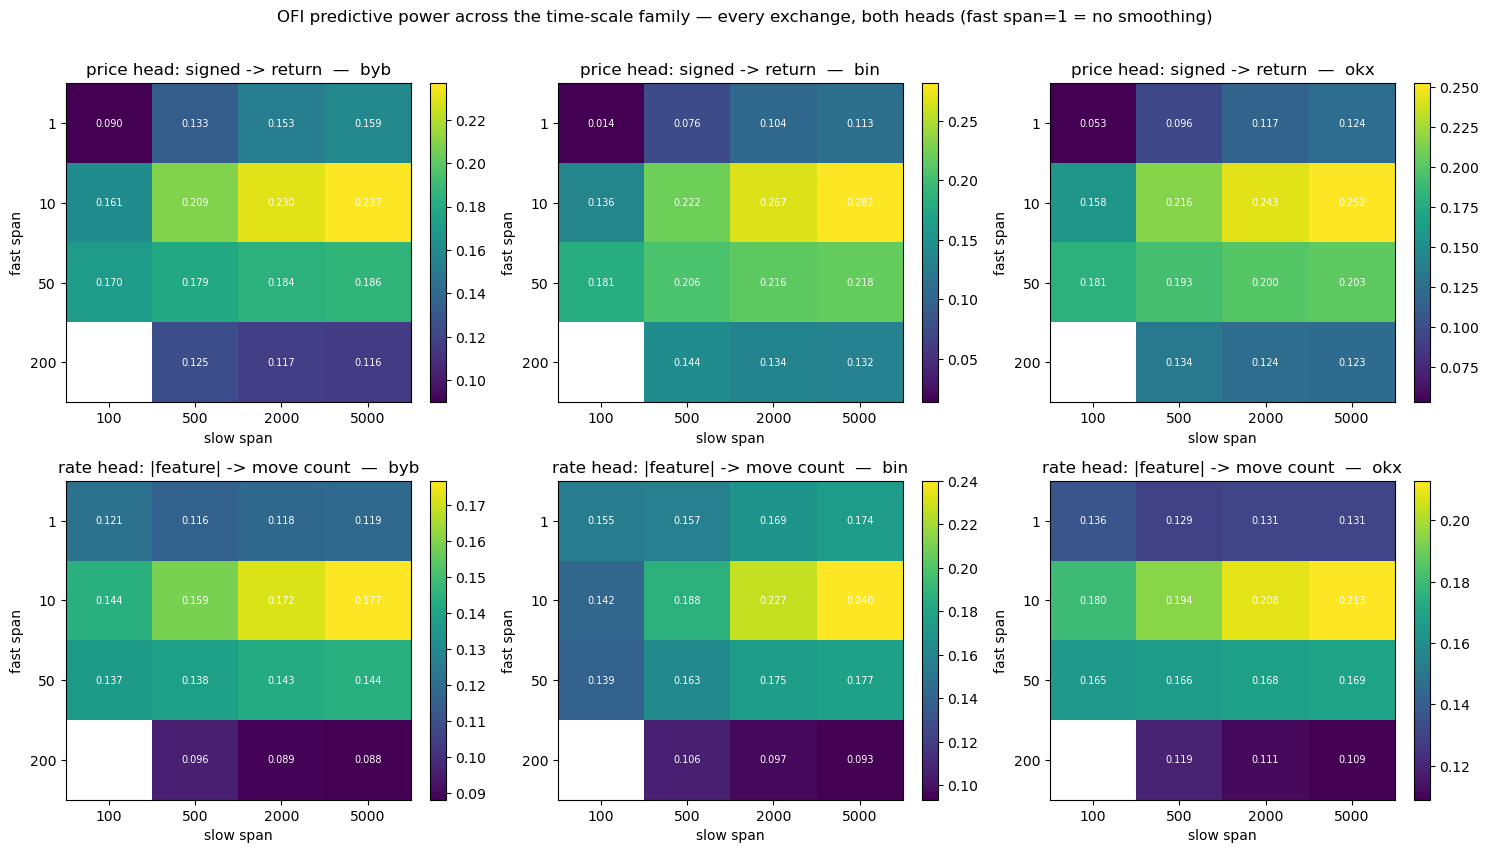

kept features (one per exchange, all fed to the model — none privileged):
  byb:  price head (fast=10, slow=5000) power=+0.237   |  rate head (fast=10, slow=5000) power=+0.177
  bin:  price head (fast=10, slow=5000) power=+0.282   |  rate head (fast=10, slow=5000) power=+0.240
  okx:  price head (fast=10, slow=5000) power=+0.252   |  rate head (fast=10, slow=5000) power=+0.213


In [6]:
# rate-head target = byb moves (trade clock) in the next 100 ms, ÷ λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual" (the constant horizon factor drops out of the rank correlation)

# Build each exchange's OWN-book OFI flow, then sweep the fast/slow family for BOTH heads, all exchanges symmetrically.
EX_LIST = ["byb"] + OTHERS                              # byb (the target's own book) + bin, okx — never privilege one
ofi_flows = {ex: ofi_stream(f"{ex}_{COIN}") for ex in EX_LIST}    # (rx, e) per venue's book
def ofi_ex(ex, n_fast, n_slow):                        # the OFI feature from exchange `ex`'s own book
    rx, e = ofi_flows[ex]
    Ef = _flow_at(anchor_ts, rx, e, n_fast); Wf = _flow_at(anchor_ts, rx, np.ones(e.size), n_fast)
    Es = _flow_at(anchor_ts, rx, e, n_slow); Ws = _flow_at(anchor_ts, rx, np.ones(e.size), n_slow)
    fast = Ef / np.where(Wf == 0.0, np.nan, Wf); slow = Es / np.where(Ws == 0.0, np.nan, Ws)
    return fast - slow                                 # sign-stable difference (never inverts when the slow leg crosses 0)

price_grid = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EX_LIST}   # signed feature -> byb's signed return
rate_grid  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EX_LIST}   # |feature|      -> byb's move count
feat_cache = {}                                                                # (ex, nf, ns) -> the signed OFI difference (reused by §6 second-span / gates / echo-netting)
for ex in EX_LIST:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            d = ofi_ex(ex, nf, ns); feat_cache[(ex, nf, ns)] = d
            fin = np.isfinite(d) & np.isfinite(target)
            price_grid[ex][i, j] = spearmanr(d[fin], target[fin]).statistic         # predictive power for the price head
            finr = np.isfinite(d) & np.isfinite(rate_target)
            rate_grid[ex][i, j]  = spearmanr(np.abs(d[finr]), rate_target[finr]).statistic  # rate head — |feature|→count is a univariate DIAGNOSTIC; the model is fed signed d

fig, axes = plt.subplots(2, len(EX_LIST), figsize=(5.0 * len(EX_LIST), 8.4), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: signed -> return"), (rate_grid, "rate head: |feature| -> move count")]):
    for col, ex in enumerate(EX_LIST):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"{head}  —  {ex}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("OFI predictive power across the time-scale family — every exchange, both heads (fast span=1 = no smoothing)", y=1.01)
fig.tight_layout(); plt.show()

# We do NOT pick an exchange. Each grid cell is IN-SAMPLE; best_member is the in-sample argmax used ONLY to PICK a time-scale.
# The chosen feature is re-scored OUT-OF-SAMPLE by the §5 walk-forward gates below — that is the number that counts.
def best_member(grid): return np.unravel_index(np.nanargmax(grid), grid.shape)
price_member = {ex: best_member(price_grid[ex]) for ex in EX_LIST}
rate_member  = {ex: best_member(rate_grid[ex])  for ex in EX_LIST}
print("kept features (one per exchange, all fed to the model — none privileged):")
for ex in EX_LIST:
    pi, pj = price_member[ex]; ri, rj = rate_member[ex]
    print(f"  {ex}:  price head (fast={FAST[pi]}, slow={SLOW[pj]}) power={price_grid[ex][pi, pj]:+.3f}"
          f"   |  rate head (fast={FAST[ri]}, slow={SLOW[rj]}) power={rate_grid[ex][ri, rj]:+.3f}")

**Reading the heat-maps.** Each cell is an in-sample rank-IC for one (fast, slow) pair and one
exchange's own-book OFI. The **sign** of the price-head map matters: OFI is signed so that *positive*
flow precedes *up* moves, and on this block every price-head cell is **positive** — confirming the §1
mechanism. The IC rises with both spans and peaks at the lightly-smoothed-fast / long-slow corner
`(fast=10, slow=5000)` for **all three** venues — byb's own book **+0.237**, **bin +0.282** (the
strongest, its sub-ms-fresh trade feed), **okx +0.252**. The rate-head map (`|OFI| → count`) peaks at the
*same* `(10, 5000)` cell for every venue (byb +0.177, bin +0.240, okx +0.213) — a strong in-sample
intensity readout. We keep every venue (leadership rotates; §9) and pick only the best (fast, slow) per
exchange/head — an in-sample pick used only to choose a time-scale; the §5 gates below re-score it
out-of-sample, and Gate A tests whether the magnitude that feeds the rate head is regime-clean (it is
**not** — see the gate conclusion).

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt (f=1,s=5000) IC|best +0.076;  OOS joint +0.206 vs solo +0.216 (Δ-0.011)  ->  one span suffices (no OOS gain)


  bin: best alt (f=50,s=5000) IC|best +0.115;  OOS joint +0.259 vs solo +0.252 (Δ+0.007)  ->  one span suffices (no OOS gain)


  okx: best alt (f=50,s=5000) IC|best +0.086;  OOS joint +0.233 vs solo +0.227 (Δ+0.006)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt (f=50,s=5000) IC|best +0.063;  OOS joint +0.155 vs solo +0.150 (Δ+0.005)  ->  one span suffices (no OOS gain)


  bin: best alt (f=50,s=5000) IC|best +0.101;  OOS joint +0.220 vs solo +0.212 (Δ+0.007)  ->  one span suffices (no OOS gain)


  okx: best alt (f=10,s=100) IC|best +0.085;  OOS joint +0.186 vs solo +0.182 (Δ+0.004)  ->  one span suffices (no OOS gain)


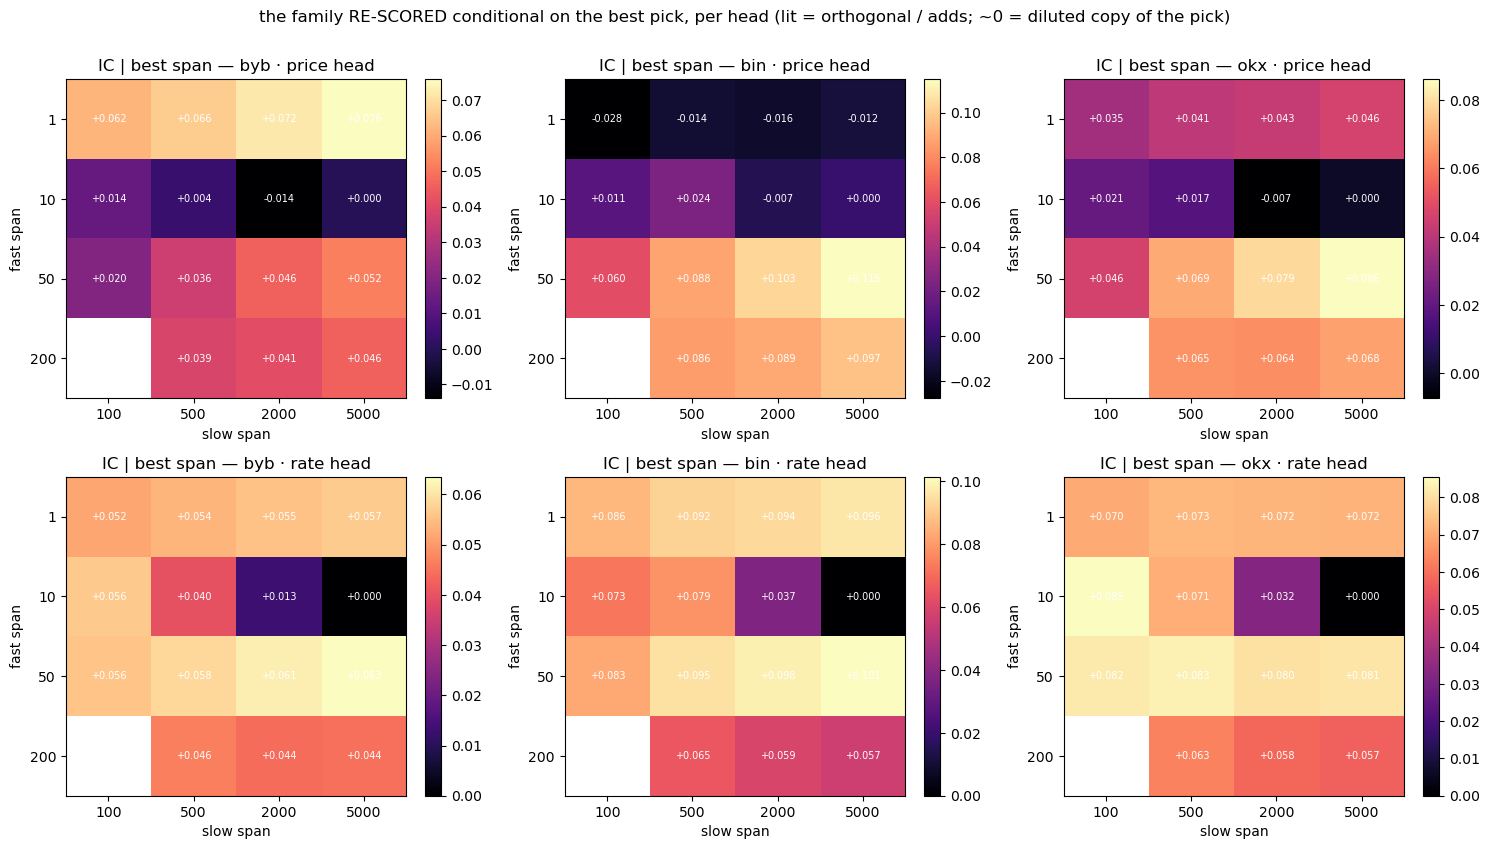

In [7]:
# === Does a SECOND time-scale ADD over the pick? — the sweep RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best span per head by IC; now re-score the WHOLE family as
# partial-IC(cell | chosen) -- each cell's IC against the head's target, CONTROLLING for the span we picked (the
# same partial-IC tool the echo-netting cell uses; control = the chosen span, not the trailing move).
# A cell still LIT adds signal ORTHOGONAL to the pick; a cell that COLLAPSES to ~0 is a diluted copy. The heat-map
# is in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a cell to its scored feature, tgt is the head's target, member is the in-sample pick.
HEADS = [("price head", lambda ex, nf, ns: ofi_ex(ex, nf, ns),         target,      price_member),
         ("rate head",  lambda ex, nf, ns: np.abs(ofi_ex(ex, nf, ns)), rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), len(EX_LIST), figsize=(5.0 * len(EX_LIST), 4.2 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    for col, ex in enumerate(EX_LIST):
        ci, cj = member[ex]; chosen = feat(ex, FAST[ci], SLOW[cj])
        cond = np.full((len(FAST), len(SLOW)), np.nan)
        for i, nf in enumerate(FAST):
            for j, ns in enumerate(SLOW):
                if nf < ns: cond[i, j] = 0.0 if (i, j) == (ci, cj) else _pic(feat(ex, nf, ns), tgt, chosen)
        ax = axes[row][col]; im = ax.imshow(cond, cmap="magma", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"IC | best span — {ex} · {head}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(cond[i, j]): ax.text(j, i, f"{cond[i, j]:+.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
        bi, bj = np.unravel_index(np.nanargmax(np.abs(cond)), cond.shape)          # the most-orthogonal alternative cell (in-sample screen)
        f1, f2 = chosen, feat(ex, FAST[bi], SLOW[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                       # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                        # the OOS joint gain DECIDES
        second[(head, ex)] = (bi, bj) if keep else None
        print(f"  {ex}: best alt (f={FAST[bi]},s={SLOW[bj]}) IC|best {cond[bi, bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
fig.suptitle("the family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC heat-map picks the best span per head; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole family conditional on
the chosen pick** — each cell's IC recomputed as `partial-IC(cell | chosen)`: its predictive power against the
head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting cell
uses; control = the chosen span). A cell that stays **lit** is **orthogonal** — it adds new signal — while
a cell that **collapses to ≈ 0** is a diluted copy of the pick. Because that heat-map is **in-sample**, the
keep/drop **decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC
(`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second span only when the out-of-sample gain clears the ~0.01
floor. We run it for **both heads** (price → signed feature vs the σ-return target; rate → |feature| vs the count
target).

**Now the gates** — and they are **two independent tests**, not one. Every *marginal* number is the
**walk-forward** mean (causal, purged); the one exception is the control-standalone **stratified** IC, which is
in-sample decoupled (its out-of-sample confirmation comes from the multi-block harness in `tools/oss`).

One caveat for **both heads**: the fast/slow pair is chosen by the in-sample heat-map *above* over the
**whole** block, so the walk-forward IC below is **post-selection and provisional** — mildly optimistic,
since the test folds also informed the pair pick. Held-out span selection is deferred to the multi-block
`tools/oss` harness; here the choice is among a small 4×4 fast/slow grid (15 valid pairs) of near-identical
neighbours, so the selection bias is expected to be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude, so a magnitude that tracks the regime would leak
into it), two leak modes against **both
regime coordinates** (vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want
**< ~0.05** for the signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its
per-decile *means* (want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. Each closes
what the others miss: scale alone passes `z + c·vol_level` (flat std, mean rides the regime); the monotone IC
misses a *U-shaped* leak (`z + |rank(vol) − 0.5|`) that only dispersion catches; and a feature flat in signed
mean and scale can still leak through its *magnitude* into the |·|-fed rate head, which only the magnitude
checks see. The vol/rate level is only the regime *coordinate* here (what we bucket/correlate against),
**never** a control. Fail any
one of them = a level in disguise, not a feature. *(We gate the §8-shaped feature — see the cell below — since
the raw fat-tailed difference is what the network never sees and is what the linear walk-forward fit would otherwise be hijacked by.)*

**Gate B — predictive signal**: does it predict? Because *a control can itself be a valid feature*,
"signal **over** the controls" only makes sense for a feature that **isn't** a control. `ofi`
is an order-flow **alpha** (not a regime descriptor), so Gate B is its **marginal** rank-IC over the
regime-invariant controls (the momenta — **never** the raw levels), all exchanges together and each on
its own, want ≳ 0.01. *(A **control-type** feature — a regime descriptor like σ_ev/λ_ev — is instead
judged on its **standalone** signal, since marginal-over-its-own-controls is circular.)* **Mechanical-coupling
guard:** the gate scores the **σ_ev price target** (`fwd_return/σ_ev`) by default, but `ofi` is a
self-centred **difference** that divides by **no** yardstick at all — it shares no denominator with either
target — so there is no spurious ratio coupling to stratify away (`STRAT_VAR = None`). We still print the
within-σ_ev stratified standalone IC below as a *confirmation* that the unstratified IC isn't a σ_ev artefact.
*Regime-stable* (companion): is Gate B still positive **within** calm, mid, and wild vol — not a one-regime artefact?

In [8]:
# The model input is the §8-shaped feature (robust z-score + clip ±4): monotone, sign-preserving, leak-free,
# and it tames the fat-tailed depth-scale difference that otherwise hijacks the linear walk-forward fit. Gate THAT.
def shape_for_model(f):
    m = np.isfinite(f)
    if m.sum() == 0: return f
    med = np.median(f[m]); mad = 1.4826 * np.median(np.abs(f[m] - med)) + 1e-12
    return np.clip((f - med) / mad, -4.0, 4.0)          # robust z then clip — the §8 transform

# Gates on the per-exchange OFI features at each venue's PRICE-head span pick — symmetric; KEEP ALL exchanges.
# Marginal value is checked JOINTLY (do the venues together add over the controls?) and per-exchange, never by picking one.
# GATE B — predictive signal. ofi is an alpha, so every leg takes the MARGINAL branch (rank-IC over the base momenta).
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers bind
# base / FEATURE_KIND / STRAT_VAR / vol_regime).
ofi_raw  = {ex: feat_cache[(ex, FAST[price_member[ex][0]], SLOW[price_member[ex][1]])] for ex in EX_LIST}
disloc   = {ex: shape_for_model(ofi_raw[ex]) for ex in EX_LIST}             # the model input (shaped)
joint = signal_ic(list(disloc.values()), own=False)
strat = signal_ic_by_regime(list(disloc.values()), own=False)
pci = wf_marginal_ci(list(disloc.values()), target)   # H5: per-fold spread + block-bootstrap CI for the headline marginal
print(f"joint Gate B marginal {joint:.3f}  |  per-fold {pci['per_fold']} (positive in {pci['pos']}/{pci['nf']})  |  block-bootstrap 90% CI [{pci['ci'][0]}, {pci['ci'][1]}]  (block ~{pci['block_len']} anchors ~{pci['block_s']}s)")
print(f"(sanity) RAW byb difference into the linear gate: marginal {round(wf_ic(base + [ofi_raw['byb']], target) - wf_ic(base, target), 3)}"
      f"  vs SHAPED: {round(wf_ic(base + [disloc['byb']], target) - wf_ic(base, target), 3)}  — a rank-IC of ONE standardized feature is invariant to a monotone reshape;"
      f" the clip matters once a feature is mixed with others in the linear design (and is what the model receives)")
rep = disloc[EX_LIST[0]]                                # representative leg — for the momenta-overlap sanity print only (Gate A runs PER EXCHANGE below)
# GATE A — regime invariance (vol_level/rate_level are the regime COORDINATE, never controls), run PER EXCHANGE
# (Gate A is a property of the output DISTRIBUTION, which differs by venue — bin is sub-ms fresh, byb/okx stale):
# scale, plus the signed feature AND its magnitude |feature| (which the signed-fed rate head can learn), each checked
# two ways x two coordinates — TRACK = |IC(., vol/rate level)| (monotone drift) and DISP = per-decile-mean dispersion
# vs vol OR rate (a NON-monotone, e.g. U-shaped, leak the monotone IC misses); each row reports the WORST coordinate.
# LOW-1 sanity: an "alpha" must NOT be a hidden regime descriptor -> its overlap with the momenta is small.
print(f"FEATURE_KIND={FEATURE_KIND!r} | feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (large for an 'alpha' => it's really a control)")
gate_rows = [dict(gate="B · signal", detail="all exchanges together — marginal over the invariant controls", value=joint)]
gate_rows += [dict(gate="B · signal", detail=f"{ex} alone — marginal over the controls",
                   value=signal_ic([disloc[ex]], own=False)) for ex in EX_LIST]
# σ_ev-coupling confirmation: ofi divides by NO yardstick (STRAT_VAR=None). A within-σ_ev stratified standalone IC ≈
# the unstratified standalone IC confirms σ_ev isn't manufacturing the rank-IC (no spurious ratio corr).
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed OFI standalone IC, unstratified", value=round(ic(disloc[ex], target), 3)) for ex in EX_LIST]
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev not manufacturing it)", value=round(stratified_ic(disloc[ex], target, sigma_at_anchor), 3)) for ex in EX_LIST]
for ex in EX_LIST:                                     # GATE A PER EXCHANGE (worst coordinate per check) — every venue, since the output distribution differs by venue
    a = gate_a(disloc[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable", detail=f"signal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(60)
pl.DataFrame(gate_rows)

joint Gate B marginal 0.268  |  per-fold [0.259, 0.283, 0.21, 0.245, 0.346] (positive in 5/5)  |  block-bootstrap 90% CI [0.262, 0.275]  (block ~2000 anchors ~100.0s)


(sanity) RAW byb difference into the linear gate: marginal 0.212  vs SHAPED: 0.212  — a rank-IC of ONE standardized feature is invariant to a monotone reshape; the clip matters once a feature is mixed with others in the linear design (and is what the model receives)


FEATURE_KIND='alpha' | feature vs momenta |IC|: rate 0.010 vol 0.007  (large for an 'alpha' => it's really a control)


gate,detail,value
str,str,f64
"""B · signal""","""all exchanges together — marginal over the invariant control…",0.268
"""B · signal""","""byb alone — marginal over the controls""",0.212
"""B · signal""","""bin alone — marginal over the controls""",0.248
"""B · signal""","""okx alone — marginal over the controls""",0.222
"""B · coupling""","""byb — signed OFI standalone IC, unstratified""",0.235
"""B · coupling""","""bin — signed OFI standalone IC, unstratified""",0.281
"""B · coupling""","""okx — signed OFI standalone IC, unstratified""",0.25
"""B · coupling""","""byb — signed standalone IC WITHIN σ_ev strata (≈ unstratifie…",0.233
"""B · coupling""","""bin — signed standalone IC WITHIN σ_ev strata (≈ unstratifie…",0.277


**Conclusion (price head).** **Gate B is strong and genuinely multi-venue.** The signed, §8-shaped OFI
difference adds **+0.268** walk-forward rank-IC over the controls *jointly* — positive in **5/5** OOS folds,
block-bootstrap 90% CI **[0.262, 0.275]** — and each venue contributes on its own (**byb +0.212, bin +0.248,
okx +0.222**), all far above the ~0.01 floor. The **joint marginal exceeds any single venue**, so the venues
are *not* collinear for direction — every venue's OFI carries direction information the others don't; bin is
the strongest single leg (its sub-ms trade feed), not byb's own flow. Within σ_ev strata the standalone IC
barely moves (byb 0.235→0.233, bin 0.281→0.277, okx 0.250→0.247), so the shared σ_ev isn't manufacturing it —
as expected, since this feature never divides by σ_ev. Its overlap with the momenta is tiny (|IC| rate 0.010,
vol 0.007), confirming it really is an alpha, not a control. The companion is positive — and rising — across
regimes (calm **+0.249**, mid **+0.264**, wild **+0.297**).

**Gate A passes for the SIGNED feature but the MAGNITUDE FAILS — an honest finding.** Run per exchange, the
*signed* OFI difference is regime-clean: scale wanders only **1.18 / 1.35 / 1.38×** (byb / bin / okx, all ≪ 3)
and the signed mean-track is **0.019 / 0.004 / 0.011** (≪ 0.05). **But** the **magnitude** `|feature|` — which
the signed-fed rate head can learn — clearly **tracks the regime** (mag-track **0.21 / 0.219 / 0.258**, all
≫ the ~0.1 bar) and leaks non-monotonically (per-decile dispersion **0.222 / 0.226 / 0.274**, all ≫ ~0.1). So
**OFI is a clean *signed direction* feature but its *magnitude* is a regime proxy**: a big |OFI| accompanies a
busy/volatile book, exactly the level Gate A is meant to catch. This is the price the depth-scale difference
pays for not being a bounded ratio — the sign is the alpha, the magnitude carries volatility. Verdict for the
**price head**: the *signed* direction signal clears every gate (strong, multi-venue, regime-stable); the
magnitude is **not** regime-invariant, which matters for the rate head (gated separately just below) since it
is fed the magnitude.

**Now the rate head — its own gates, against the count target.** The block above gated the *price-span*
feature against the σ_ev **price** target. The rate head is fed a **different-span** feature (the
`rate_member` pick) and predicts the **count** target, so its verdict is **not** inherited from the price
gates — it gets the same two-gate battery here.

The rate head's signal lives in the **magnitude**: `|feature| → count` is the §6 diagnostic, and the model
is fed the **signed** feature and recovers `|·|` itself (a nonlinear head can). So **Gate B scores
`|feature|`** — a *linear* score on the signed feature would read ≈ 0 precisely because the count
relationship is symmetric, so `|feature|` is the honest proxy for what the nonlinear rate head extracts.
**Coupling guard:** the price head used `STRAT_VAR=None` because the OFI difference divides by no yardstick;
the magnitude path has no sign, but `|feature|` carries no `1/λ_ev` factor while `count/λ_ev ∝ 1/λ_ev`, so
they share no denominator — we add a within-λ_ev stratified line per exchange to confirm the marginal isn't a
`1/λ_ev` artefact regardless. **Gate A** is re-run **per exchange** on the rate-span feature (a distribution
property — it differs by venue *and* by span).

In [9]:
# === RATE-HEAD GATES ===
# The price-head gates above ran the price-SPAN feature against the σ_ev price target. The rate head is fed a
# DIFFERENT-span feature (the rate_member pick) and predicts the COUNT target, so its verdict can't be inherited
# from the price gates — it gets the SAME two-gate battery here, against the count target.
#  * The rate head's signal lives in the MAGNITUDE: |feature|->count is the §6 diagnostic, and the model is fed the
#    SIGNED feature and recovers |.| internally (a nonlinear head can). So Gate B scores |feature| — a LINEAR score
#    on the signed feature reads ~0 because the count relationship is symmetric; |feature| is the honest proxy.
#  * Coupling guard: |feature| carries no 1/λ_ev factor while count/λ_ev ~ 1/λ_ev — no shared denominator — but we
#    add a within-λ_ev stratified line per exchange to confirm the marginal is not a 1/λ_ev artefact.
#  * Gate A is re-run PER EXCHANGE on the rate-span feature (a distribution property — it differs by venue AND by span).
disloc_rate = {ex: feat_cache[(ex, FAST[rate_member[ex][0]], SLOW[rate_member[ex][1]])] for ex in EX_LIST}
mag_rate    = {ex: shape_for_model(np.abs(disloc_rate[ex])) for ex in EX_LIST}   # |feature|, §8-shaped (the model input the rate head sees)

joint_rate  = signal_ic(list(mag_rate.values()), own=False, tgt=rate_target)            # |feature|->count, marginal over the controls, all venues together
strat_rate  = signal_ic_by_regime(list(mag_rate.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion
rci = wf_marginal_ci(list(mag_rate.values()), rate_target)   # H5: per-fold spread + block-bootstrap CI for the rate-head headline marginal
print(f"joint Gate B (rate) marginal {joint_rate:.3f}  |  per-fold {rci['per_fold']} (positive in {rci['pos']}/{rci['nf']})  |  block-bootstrap 90% CI [{rci['ci'][0]}, {rci['ci'][1]}]  (block ~{rci['block_len']} anchors ~{rci['block_s']}s)")
# gate_a (worst-coordinate Gate A, used for both heads) is bound in §5.

rate_rows  = [dict(gate="B · signal (rate)", detail="all exchanges together — marginal |feature|->count over the controls; want >~ 0.01", value=joint_rate)]
rate_rows += [dict(gate="B · signal (rate)", detail=f"{ex} alone — marginal |feature|->count over the controls",
                   value=signal_ic([mag_rate[ex]], own=False, tgt=rate_target)) for ex in EX_LIST]
rate_rows += [dict(gate="B · coupling (rate)", detail=f"{ex} — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)",
                   value=round(stratified_ic(mag_rate[ex], rate_target, lam_at_anchor), 3)) for ex in EX_LIST]
for ex in EX_LIST:
    a = gate_a(disloc_rate[ex])
    rate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — the rate head sees |feature|, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
rate_rows += [dict(gate="regime-stable (rate)", detail=f"|feature|->count within {nm}-vol (companion: stay positive)", value=strat_rate.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(rate_rows)

joint Gate B (rate) marginal 0.171  |  per-fold [0.149, 0.198, 0.141, 0.155, 0.21] (positive in 5/5)  |  block-bootstrap 90% CI [0.161, 0.177]  (block ~9479 anchors ~474.0s)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""all exchanges together — marginal |feature|->count over the controls; …",0.171
"""B · signal (rate)""","""byb alone — marginal |feature|->count over the controls""",0.086
"""B · signal (rate)""","""bin alone — marginal |feature|->count over the controls""",0.148
"""B · signal (rate)""","""okx alone — marginal |feature|->count over the controls""",0.114
"""B · coupling (rate)""","""byb — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.139
"""B · coupling (rate)""","""bin — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.207
"""B · coupling (rate)""","""okx — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.168
"""A · regime-inv (byb)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.5
"""A · regime-inv (byb)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want <…",0.019


**Conclusion (rate head).** **Gate B is clearly positive — but Gate A's magnitude leak from above is the
catch.** The §8-shaped `|feature| → count` marginal over the controls is **+0.171** jointly (positive in
**5/5** OOS folds, CI **[0.161, 0.177]**), **byb +0.086, bin +0.148, okx +0.114** on their own — all above
the ~0.01 floor, bin the strongest. *Within* **λ_ev strata** the signal stays robustly positive (**0.139**
byb, **0.207** bin, **0.168** okx), so the marginal is **not** a `1/λ_ev` arithmetic artefact — the intensity
signal is real, not a yardstick coupling. The companion is positive in every regime (calm **+0.153**, mid
**+0.166**, wild **+0.167**). **Gate A, however, does NOT hold for the magnitude:** scale is fine (**1.5 /
1.62 / 1.83×**, under 3) and the *signed* mean-track is tiny (0.019 / 0.004 / 0.011), but the **`|feature|`
the rate head actually sees tracks the regime** (mag-track **0.213 / 0.218 / 0.26**, all ≫ ~0.1) and leaks
non-monotonically (dispersion **0.343 / 0.282 / 0.459**, all ≫ ~0.1). So the rate-head signal is **partly a
volatility/activity proxy**: a large |OFI| genuinely precedes more byb moves, but it also *coincides* with a
busier regime, and Gate A cannot separate the two here. The honest rate-head verdict: a real OOS intensity
edge (~+0.17 joint, survives the λ_ev stratification) **caveated by a magnitude that is not regime-invariant**
— the marginal-over-momenta gain is genuine, but the model should expect the rate-head |OFI| read to carry
regime as well as forward intensity (the two are not cleanly separable on this block).

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

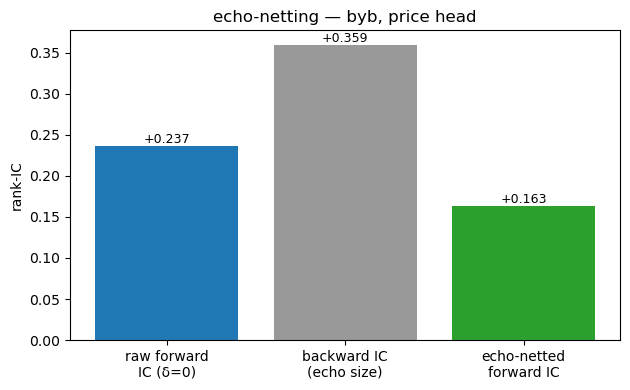

raw forward IC +0.237;  backward (echo) IC +0.359;  echo-netted forward IC +0.163  (the raw->netted shortfall is echo)


In [10]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = "byb"                                          # byb's own-book OFI illustrates it (it carries the largest backward echo); every venue carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = feat_cache[(rep_ex, FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]])]   # the chosen price-head feature
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_ex}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when a foreign venue's book moves before byb's
reflects it (byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and
exploitable**, and the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do
**not** coarsen the foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be
fake if the recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here,
where the recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by the feature
and look at the real distributions the two heads care about:
- **price head:** byb's next return for low / middle / high feature values — it should tilt one way as
  OFI turns positive and the other as it turns negative;
- **rate head:** how the number of upcoming moves grows as the feature's *magnitude* grows.

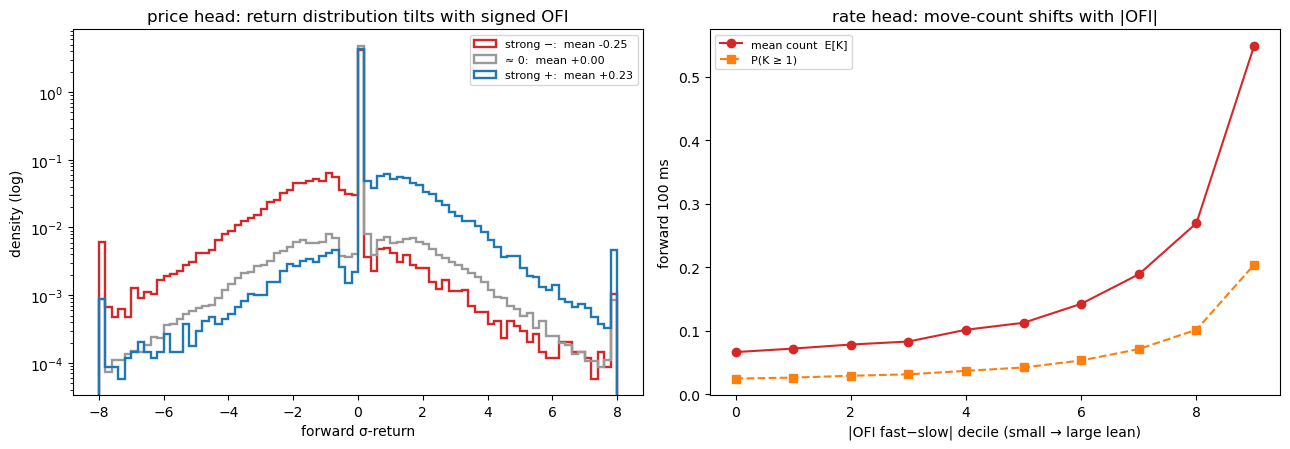

price head group means (strong−, ≈0, strong+): [-0.246, 0.001, 0.232]
rate head E[K] by |OFI| decile (small->large): [0.07, 0.07, 0.08, 0.08, 0.1, 0.11, 0.14, 0.19, 0.27, 0.55]


In [11]:
rep_ex = "byb"                                                                  # byb's own-book OFI illustrates the shape; the model uses every exchange
signed = feat_cache[(rep_ex, FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]])]
absmag = np.abs(feat_cache[(rep_ex, FAST[rate_member[rep_ex][0]], SLOW[rate_member[rep_ex][1]])])   # the RATE-head's own span pick
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-OFI buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    mm = m & np.isfinite(target)
    axA.hist(np.clip(target[mm], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[mm]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: return distribution tilts with signed OFI"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |OFI|
fin = np.isfinite(absmag)
dec = np.full(absmag.shape, -1); dec[fin] = np.digitize(absmag[fin], np.nanpercentile(absmag[fin], np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|OFI fast−slow| decile (small → large lean)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count shifts with |OFI|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()
print("price head group means (strong−, ≈0, strong+):",
      [round(float(np.nanmean(target[m & np.isfinite(target)])), 3) for _, m, _ in groups])
print("rate head E[K] by |OFI| decile (small->large):", [round(float(fwd_count[dec == b].mean()), 2) for b in range(10)])

**Conclusion.** The feature moves the *actual outcome distributions* the two heads need — not just a single
summary number (shown here for byb's own flow; the model uses every venue). **Price head (left):** the
forward-return distribution shifts bodily with the *signed* feature — mean σ-return **−0.246** for the
strong-negative group, **+0.232** for strong-positive, **+0.001** (flat) for the ≈0 group between — so the
sign genuinely carries direction (the feature's main job), in exactly the direction §1 predicts (positive OFI
→ up). **Rate head (right):** the mean move-count `E[K]` climbs monotonically with the |OFI| decile, from
**0.07** in the smallest-lean decile to **0.55** in the largest — and `P(K ≥ 1)` rises with it — so a large
flow imbalance does precede more moves. Both heads have something to learn here; the §6/Gate-A caveat is that
the rate head's |OFI| signal is partly entangled with the regime (the magnitude tracks volatility), so the
intensity tilt is real but not regime-clean.

## 8. Input shaping for the network

This is a *different* step from §2. OFI is a self-centred **difference** of two same-units legs, so
there's no volatility to divide out (§2 noted it's self-scaling). Here we reshape it for the network's
input — roughly centred, unit-scale, no wild outliers. A *difference of two depth-scale E/W means* is
symmetric but **fat-tailed** (depth events span orders of magnitude: a few book updates carry far more
quantity than the median), so we expect this feature to need more than a plain z-score — though *not* the
~1e5 spikes the old ratio had (a difference cannot blow up at a near-zero denominator). Pick the
**lightest** transform that meets the bar; the QQ-plot makes the choice.

feature: std=19  skew=+0.42  excess_kurt=42.8  (0 = normal)
  z-score            excess_kurt=    42.8   max|·|=35.7
  robust + clip ±4   excess_kurt=     0.9   max|·|=4.0
  arcsinh(robust)    excess_kurt=     0.9   max|·|=5.5
  rank-Gaussian      excess_kurt=    -0.0   max|·|=5.0


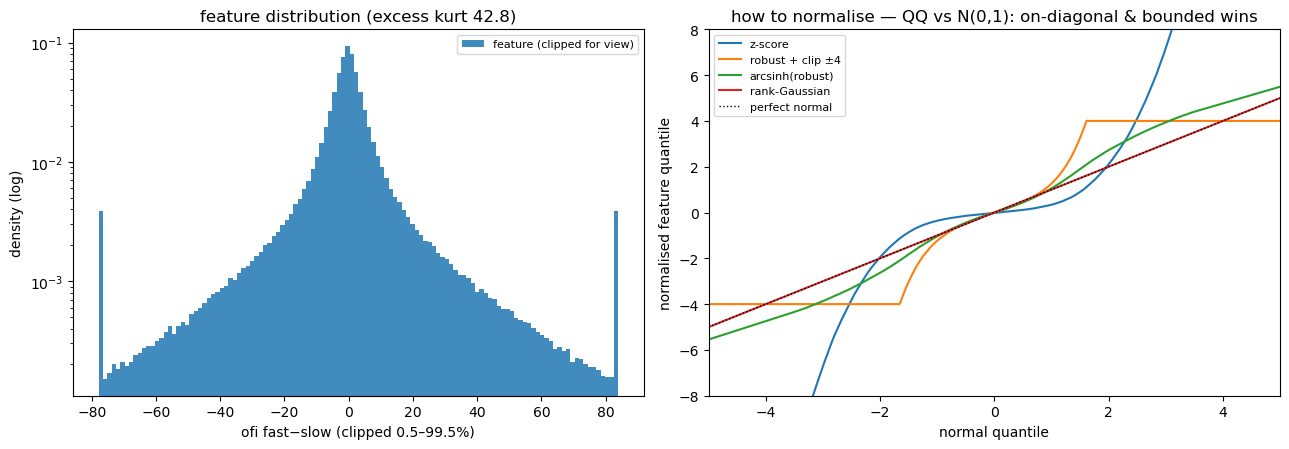

In [12]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = "byb"
f = feat_cache[(rep_ex, FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]])]; f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: std={f.std():.2g}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>8.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
lo_p, hi_p = np.percentile(f, [0.5, 99.5])
axA.hist(np.clip(f, lo_p, hi_p), bins=120, density=True, color="C0", alpha=.85, label="feature (clipped for view)")
axA.set_yscale("log"); axA.set_xlabel("ofi fast−slow (clipped 0.5–99.5%)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution (excess kurt {kurtosis(f):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_ylim(-8, 8); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles the transform. As a **difference of two depth-scale E/W means**, OFI is
near-symmetric (skew **+0.42**) but heavily **fat-tailed** (excess kurtosis **42.8**, std **≈19**), so a
plain z-score leaves a wild **35.7σ** outlier and fails the "no wild outliers" bar. The lightest transform
that *meets* it is a robust z-score followed by a clip (**robust + clip ±4 → max|·| = 4.0, excess kurt 0.9**)
— or, if the tail were worse, a rank-Gaussian map (max|·| 5.0, excess kurt ≈0), the heaviest, which flattens
any tail by construction. The QQ-plot points to the on-diagonal, bounded **robust + clip ±4** curve; use that
whenever you feed a network (it is the §5-gated feature). The tail is real but bounded — no ~1e5 ratio spikes
(a difference can't blow up at a near-zero denominator) — so the clip throws away very little.

**Still to run** (same machinery): whether the feature adds over features we already have;
whether the signal is steady day-to-day; and whether it survives out-of-sample across a
market-regime change. (The leak check *inside* volatility buckets is no longer pending —
Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-exchange worth it? (for a poolable feature)

OFI is **poolable** — each venue yields its own one-number OFI difference from its own book — so unlike
the template's cross-venue gap, you face a real choice: keep them **per-exchange**, collapse to **one**
(byb's own book, the most direct), or **pool** them. The right answer depends on the time-scale, so
sweep it and compare the three. The §6 heat-maps already give the full per-exchange numbers across the
family, and §5's gates score each venue's contribution out-of-sample (jointly and on its own) — those are
the real per-exchange measurements for this feature.

> **The table below is an illustrative pattern for a poolable order-flow feature — it is NOT computed for
> `ofi` here** (whose real per-exchange numbers are the §6 heat-maps and the §5 per-venue gate rows). It
> sketches the typical pattern, predicting byb's next 100 ms. The ms/second labels just translate points on
> the trade-span N clock for readability; the actual sweep is over trade-span N, as everywhere else.

| time-scale | pooled | best single (byb book) | per-exchange | what it means |
|---|---|---|---|---|
| ≤ 50 ms | mid | high | **high** | byb leads its own mid AND foreign flow leads by a beat — keep all |
| middle band | mid | mid | **high** | another venue's flow leads byb — separate venues add most |
| long | low | low | low | flow drift is shared — any one venue will do |

So keep all exchanges as the safe default, and sweep per-exchange / single / pooled rather than pool by
default — pooling tends to blur the middle band. (Longer prediction horizons widen the useful band, so sweep
the horizon too.)

## 10. The verdict, and what it takes to ship

**Keep it — feed the *signed*, §8-shaped OFI difference (`fast − slow`) to both heads (each head gated
separately in §6), all exchanges, at the chosen `(fast=10, slow=5000)` pick — with one honest caveat: the
direction edge is strong and clean, but the *magnitude* that the rate head reads is NOT regime-invariant.**
The verdict numbers are read off this run's executed gate tables and the echo-netting printout.
- **Price head (direction, its main job) — strong, clean, multi-venue.** The signed OFI difference clears
  every gate. Gate B is **+0.268** joint walk-forward (5/5 folds, CI [0.262, 0.275]), and the venues are
  **not** collinear — the joint *exceeds* any single venue (byb **+0.212**, bin **+0.248**, okx **+0.222**);
  bin is the strongest single leg (sub-ms feed). No σ_ev artefact (within-strata IC ≈ unstratified), and
  Gate A on the *signed* feature passes (scale 1.18–1.38×, mean-track 0.004–0.019), regime-stable (calm/mid/
  wild +0.249 / +0.264 / +0.297). Buy pressure → byb ticks up; the sign **never inverts** (a difference, not
  a ratio). byb's own-book leg is built from the book that *moves byb's mid*, so it carries a large backward
  echo (+0.359) — once that trailing move is partialled out, its honest headline is the **echo-netted +0.163**:
  discounted by the echo but still a clear forward lead, not a pure echo (that netted number, not the raw δ=0,
  is what byb's verdict quotes). Keep every venue (leadership rotates).
- **Rate head (intensity, secondary) — a real edge, but entangled with the regime.** The §8-shaped `|OFI| →
  count` marginal is **+0.171** joint OOS (5/5 folds; byb +0.086, bin +0.148, okx +0.114), and it survives
  the within-λ_ev stratification (0.139 / 0.207 / 0.168), so it is **not** a `1/λ_ev` artefact. **But Gate A
  fails on the magnitude** the rate head actually sees: `|feature|` tracks the regime (mag-track 0.21–0.26,
  dispersion 0.28–0.46, all well above the ~0.1 bars) — a large |OFI| coincides with a busy/volatile book.
  So the rate-head signal is genuine forward intensity *plus* a volatility proxy the gates cannot cleanly
  separate on this block. The model is still fed the **signed** feature (never a pre-computed `|OFI|`), and
  the rate head recovers the magnitude itself — but expect it to carry regime as well as forward intensity.

Feed **every exchange's** signed OFI difference and let the model lean on whichever venue is leading;
don't collapse to one "leader." OFI is a **difference** (not a ratio), so it ships **without** a `σ_ev`
division — but it is *not* self-bounding: a difference of depth-scale legs is fat-tailed, so it **must** go
through the §8 robust-z + clip ±4 before the network (the model never sees the raw difference; §5 gates the
shaped feature). The move-count it (secondarily) predicts is divided by the rate yardstick `λ_ev` in the
target.

**Why a difference, not the original ratio.** The first cut used `fast / slow`, which **inverts sign**
whenever the slow leg crosses zero — fatal for a signed direction feature. `fast − slow` never inverts,
and (a bonus) makes the §4 parity check genuinely **bit-exact** (no near-zero-denominator amplification to
relabel away).

**Clock choice (stated plainly).** OFI is a **flow injected on byb front_levels updates** and **decayed
once per trade-timestamp** on the shared bin/byb/okx merged trade clock (`merged_ts = np.unique(...)`,
simultaneous prints = one tick), read as an `E/W` per-event mean — exactly the template's `σ_ev` machine
pointed at OFI increments. It updates on every byb book change between trades and is read live at the grid
anchor; it never reads a stale last-trade state. Same-nanosecond byb book rows are one EMA sample —
value = the **SUM** of their per-row OFI increments (the full intra-ns path, the **path-sum** variant), not
the collapsed endpoint.

**To ship:**
- [x] the streaming (constant-work-per-trade) builder, matching this analysis version — done (§4, production `boba.ema` `KernelMeanEMA`, bit-exact: legs/feature absolute round-off `< 1e-9`)
- [x] the parity check (§4), production-style `boba.ema` streaming vs §3's vectorized path, passing on a real block
- [ ] the tests, passing
- [ ] both heads gated **out-of-sample** (§5 walk-forward) — recorded; rate head read off its own table
- [ ] the gate results recorded (with any failures justified)
- [ ] the chosen heads and time-scales written down, with the yardstick span (YARDSTICK_N=10000)
- [x] the data quirks handled (bad zero-price prints filtered; byb front_levels qty used; same-ns rows path-summed into one sample)